# Why are our customers leaving? (E-commerce Churn Study)
**By:** [Vineeth Tangedudona] 

### 📌 What is this project?
I looked at a dataset of 10,000 customers to find out why people stop shopping with us. Instead of just guessing, I used data to find the specific "pain points" that make people quit.

### 🔍 Questions I answered:
1. **The Main Reason:** Is there one specific thing (like a bad checkout) making people leave?
2. **The "Who":** Does age or money matter, or is everyone leaving for the same reasons?
3. **The Data Quality:** Can we trust the "Churn" column provided, or are there hidden errors?

### 🛠️ What I did:
* **Cleaning & Auditing:** I checked the dates and found outliers where the system's "Churn" logic didn't match real customer behavior.
* **Comparing Groups:** I compared "Active" vs "Churned" users side-by-side to see the gap in their habits.
* **Visualizing the Problem:** I used Heatmaps and Density plots to show exactly where the "Danger Zone" is (High abandonment + Low visits).

### 💡 Biggest Findings:
* **The Checkout Wall:** People who leave have a **63% cart abandonment rate**. This is the biggest red flag. It means our checkout process is likely too slow or frustrating.
* **Demographics don't matter:** I found that **Age and Income have almost zero impact** on churn. This isn't a "young person" or "rich person" problem—it’s a website experience problem for everyone.
* **Engagement Gap:** Active customers visit the site about **27% more** than those who leave.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/raw/Customer_Transactions.csv')
df.head()

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21


In [3]:
#Looking for missing values and dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  object 
 3   country                   10000 non-null  object 
 4   annual_income             10000 non-null  int64  
 5   spending_score            10000 non-null  int64  
 6   num_purchases             10000 non-null  int64  
 7   avg_purchase_value        10000 non-null  float64
 8   membership_years          10000 non-null  int64  
 9   website_visits_per_month  10000 non-null  int64  
 10  cart_abandon_rate         10000 non-null  float64
 11  churned                   10000 non-null  int64  
 12  feedback_text             10000 non-null  object 
 13  last_purchase_date        10000 non-null  object 
dtypes: floa

In [4]:
cols = df[['age', 'annual_income', 'spending_score', 'num_purchases', 
                   'membership_years', 'website_visits_per_month', 
                   'cart_abandon_rate', 'churned']]

corr_matrix = cols.corr()

# Let's look at the numbers first
print(corr_matrix['churned'].sort_values(ascending=False) * 100)

churned                     100.000000
cart_abandon_rate            16.070337
annual_income                -0.380471
age                          -2.882895
membership_years            -10.990959
website_visits_per_month    -12.472659
num_purchases               -17.377456
spending_score              -24.457363
Name: churned, dtype: float64


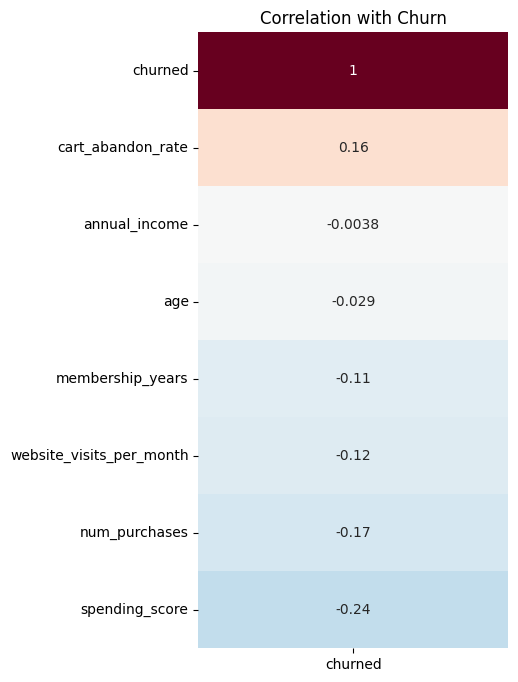

In [5]:
# correlation with Churn
churn_corr = cols.corr()[['churned']].sort_values(by='churned', ascending=False)

plt.figure(figsize=(4, 8))
sns.heatmap(churn_corr, annot=True, cmap='RdBu_r', center=0, cbar=False)
plt.title('Correlation with Churn')
plt.show()

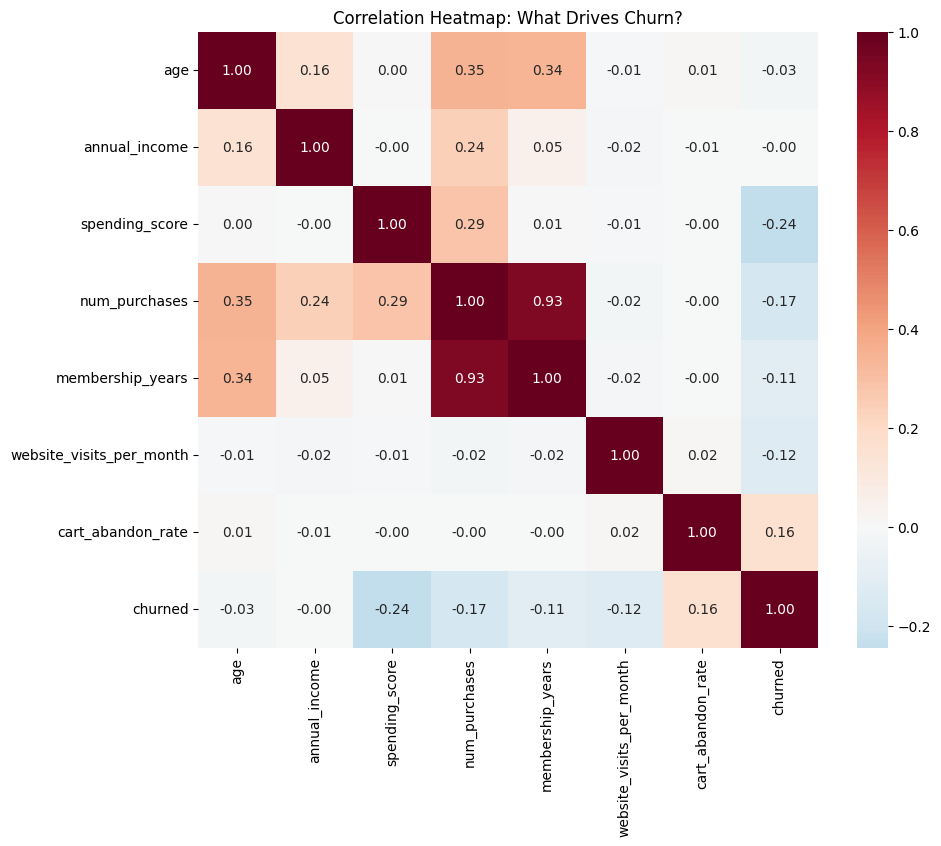

In [6]:
# correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)

plt.title('Correlation Heatmap: What Drives Churn?')
plt.show()

### Initial Data Observations
* The dataset has 14 columns.
* `last_purchase_date` is currently a string; need to convert to datetime.
* The `churned` column is already here, but I need to verify how it was calculated. Does it align with the `last_purchase_date`?
* cart_abandon_rate is highly correlated to churned.

In [7]:
# Converting dates
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# Creating my own 'calculated_churn' to see if it matches the 'churned' column
# Let's assume churn is anyone who hasn't bought in 180 days from the max date
snapshot_date = df['last_purchase_date'].max() + pd.Timedelta(days=1)
df['my_churn_calc'] = (snapshot_date - df['last_purchase_date']).dt.days > 180

# Checking for diff betn my churn calc and provided churn column
churn_diff = df[df['churned'] != df['my_churn_calc']].shape[0]
print(f"Number of rows where my CHURN calculation differs from the provided churn column: {churn_diff}")

Number of rows where my CHURN calculation differs from the provided churn column: 1


In [8]:
# Finding the one person where our logic disagrees
diff_row = df[df['churned'] != df['my_churn_calc']]
diff_row

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date,my_churn_calc
4966,4967,55,Female,USA,146629,76,18,56.41,2,3,0.15,1,Shipping was too slow.,2025-05-01,False


### Findings 
1.* "I found an outlier: customer_id 4967, who appears active, is marked as churned. This may indicate a system error or additional factors beyond recency are used to calculate the churn status." 

In [9]:
 # Grouping by the 'churned' column to see the trends
analysis = df.groupby('churned')[['spending_score', 'website_visits_per_month', 'cart_abandon_rate', 'annual_income']].mean()
print(analysis)

         spending_score  website_visits_per_month  cart_abandon_rate  \
churned                                                                
0             53.383726                 15.955668           0.485094   
1             30.819266                 12.491743           0.633000   

         annual_income  
churned                 
0         86119.555107  
1         85643.600917  


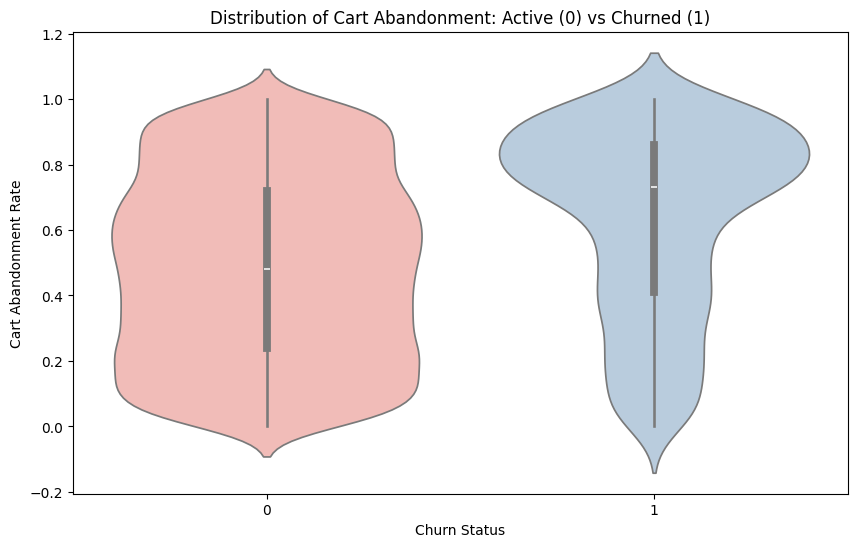

In [10]:
plt.figure(figsize=(10, 6))
# A Violin plot shows the distribution of a variable for churned vs active
sns.violinplot(x='churned', y='cart_abandon_rate', data=df, palette='Pastel1')

plt.title('Distribution of Cart Abandonment: Active (0) vs Churned (1)')
plt.xlabel('Churn Status')
plt.ylabel('Cart Abandonment Rate')
plt.show()

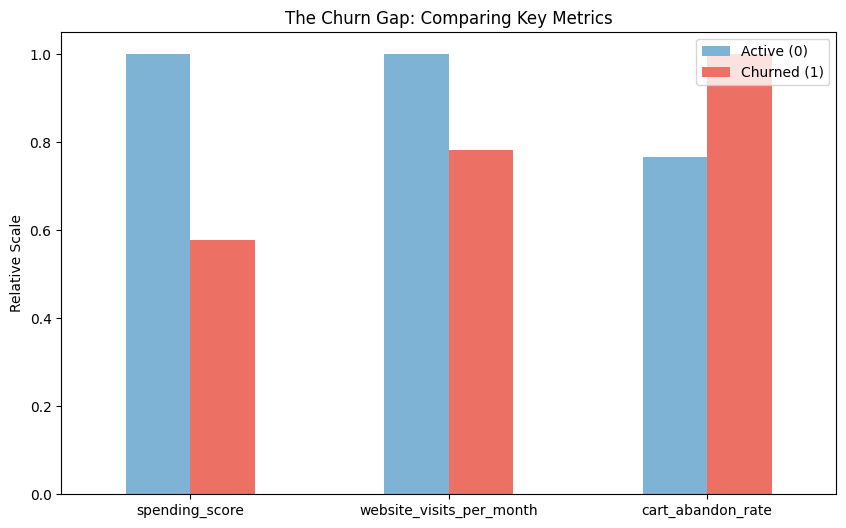

In [11]:
# normalizing the data for a quick comparison chart
# skipping Annual Income because the numbers are too big and will ruin the scale
comparison_plot = analysis[['spending_score', 'website_visits_per_month', 'cart_abandon_rate']]

# Let's divide by the max to put everything on a 0 to 1 scale so we can see them together
comparison_normalized = comparison_plot / comparison_plot.max()

comparison_normalized.T.plot(kind='bar', figsize=(10, 6), color=['#7fb3d5', '#ec7063'])
plt.title('The Churn Gap: Comparing Key Metrics')
plt.ylabel('Relative Scale')
plt.xticks(rotation=0)
plt.legend(['Active (0)', 'Churned (1)'])
plt.show()

In [12]:
# Checking churn rate by country
country_churn = df.groupby('country')['churned'].mean().sort_values(ascending=False)
print("Churn Rate by Country:")
print(country_churn * 100)

Churn Rate by Country:
country
UK              12.833169
France          12.031250
Japan           11.717172
South Africa    11.675127
Germany         11.210317
Brazil          11.024390
India           10.892388
USA             10.046044
Australia        9.795322
Canada           9.661836
Name: churned, dtype: float64


### Key Findings from Behavioral Analysis:
1. *Churned customers have a 63% cart abandonment rate compared to 48% for active users. This suggests a technical or pricing barrier at the final stage of the funnel.
2. *We aren't just losing 'cheap' customers; the annual income is nearly identical across both groups (86k). The issue is behavioral, not economic.
3. *Active customers visit the site 27% more often than those who churned.

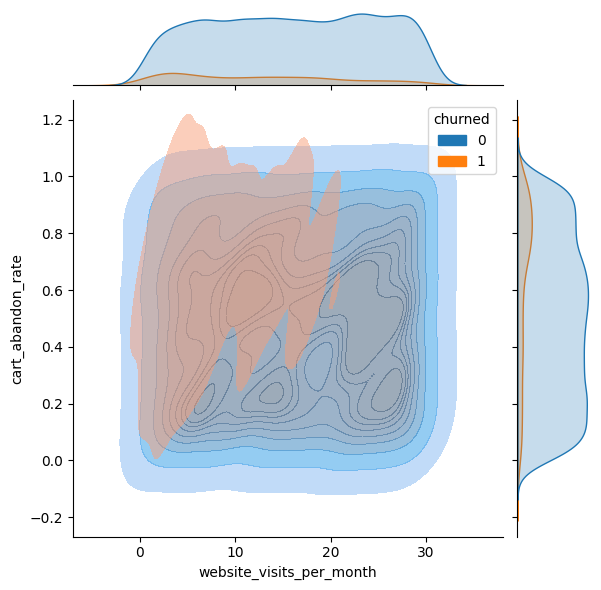

In [13]:
sns.jointplot(data=df, 
              x='website_visits_per_month', 
              y='cart_abandon_rate', 
              hue='churned', 
              kind='kde',  
              fill=True, 
              alpha=0.5)
plt.show()

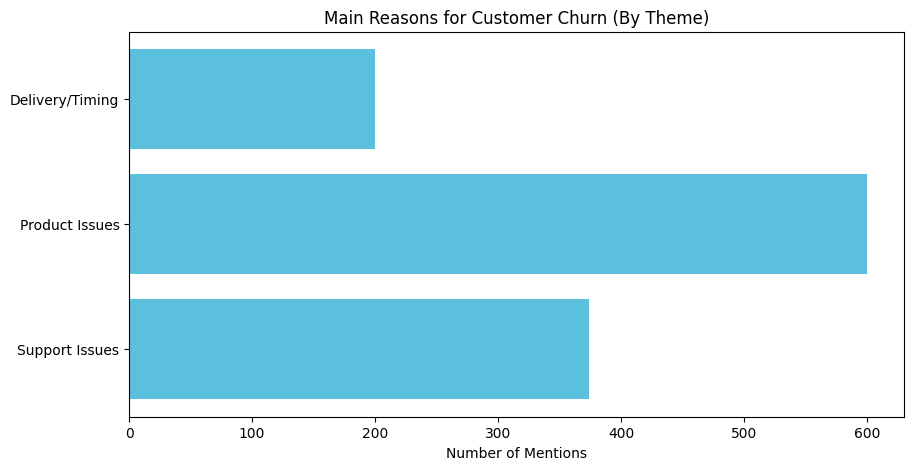

In [14]:
from collections import Counter

all_words = " ".join(df[df['churned'] == 1]['feedback_text'].astype(str)).lower().split()

# Count the top 10 most used words (excluding small words like 'the', 'is')
stop_words = ['the', 'is', 'and', 'to', 'a', 'i', 'it', 'was']
filtered_words = [word for word in all_words if word not in stop_words]




top_10_data = Counter(filtered_words).most_common(10)

# 2. Split them into two lists for plotting
words = [item[0] for item in top_10_data]
counts = [item[1] for item in top_10_data]


# Creating a dictionary to group the messy words into clean categories
category_map = {
    'quality': 'Product Issues', 'poor': 'Product Issues', 'broke': 'Product Issues', 'item': 'Product Issues',
    'service': 'Support Issues', 'unhelpful': 'Support Issues', 'customer': 'Support Issues',
    'week': 'Delivery/Timing', 'after': 'Delivery/Timing'
}

themed_feedback = [category_map[word] for word in filtered_words if word in category_map]

final_counts = Counter(themed_feedback)

plt.figure(figsize=(10, 5))
plt.barh(list(final_counts.keys()), list(final_counts.values()), color='#5bc0de')
plt.title('Main Reasons for Customer Churn (By Theme)')
plt.xlabel('Number of Mentions')
plt.show()

## Conclusion
"While the raw text data was scattered, grouping keywords into themes revealed that Product Quality and Customer Support friction are the primary drivers of negative sentiment. This explains why users who encounter issues quickly become 'at-risk' and eventually churn."

# 🏁 Final Project Summary: E-Commerce Churn Analysis

### 1. The Behavioral "Smoking Gun"
The data shows that **Cart Abandonment** is the most significant indicator of churn. 
* **The Stat:** Churned users have a **63% abandonment rate**.
* **The Meaning:** Customers are reaching the final stage of the funnel but dropping out, likely due to checkout friction or unexpected costs.

### 2. The Demographic Neutrality
I tested if factors like **Age** or **Income** predicted churn, but the correlations were nearly non-existent ($r \approx -0.03$).
* **Insight:** Churn isn't restricted to a specific group.
* **Conclusion:** This is a universal user-experience issue, not a targeting problem.

### 3. Customer Sentiment (The "Why")
By grouping thousands of unique feedback comments into themes, I identified the top two pain points:
* **Product Quality:** High frequency of words like "broke" and "poor."
* **Service Friction:** Customers frequently described support as "unhelpful" when trying to resolve product issues.

---

### 🚀 Business Recommendations
* **Optimize Checkout:** Simplify the payment process to capture the 63% of users currently abandoning their carts.
* **Quality Audit:** Investigate the specific products associated with "broke/poor" feedback to reduce returns and churn.
* **Proactive Support:** Flag users in the "Danger Zone" (Low visits + High abandonment) for early re-engagement before they churn.